In [135]:
import pandas as pd
import numpy as np


merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\FINAL.csv"
df= pd.read_csv(merged_all_with_landcover)

In [ ]:
#df.head(20)

,grid_id,month,ERA5__points_per_cell,ERA5__tmean,ERA5__tmin,ERA5__tmax,ERA5__prcp,ERA5__wind10m,ERA5__sp,ERA5__swdown,...,OpenAQ_NO2__value,OpenAQ_NO2__points_per_cell,S5P_CO__avg,S5P_CO__points_per_cell,S5P_NO2__avg,S5P_NO2__points_per_cell,AOD_LandOcean,AOD_550_dark,AOD_DeepBlue,LANDCOVER
0,1,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.324,0.282,0.226,NaN
1,1,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.324,0.282,1.201,NaN
2,1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.269,0.206,0.172,NaN
4,1,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.269,0.206,1.156,NaN
5,1,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.172,0.134,0.124,NaN
6,1,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.172,0.134,1.143,NaN
7,1,4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,0.0,0.240,0.176,0.160,NaN
8,1,4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,0.0,0.240,0.176,1.083,NaN
9,1,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,0.0,0.571,0.552,0.532,NaN


In [136]:
sub = df[df['OpenAQ_NO2__value'].notna()].copy()
print("Training rows:", len(sub))

Training rows: 4150


In [137]:
sub.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER'],
      dtype='object')

In [152]:

cols_to_drop = ['cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m', 'grid_id']

# Drop fixed columns
sub_filtered = sub.drop(columns=cols_to_drop)

# Drop all columns ending with "__points_per_cell"
sub_filtered = sub_filtered.loc[:, ~sub_filtered.columns.str.endswith("__points_per_cell")]

# Count non-missing values
non_missing_table = sub_filtered.notna().sum().reset_index()
non_missing_table.columns = ["variable", "non_missing_count"]

# Sort
non_missing_table = non_missing_table.sort_values("non_missing_count", ascending=False)

# Name of the variable you want first
first_var = "OpenAQ_NO2__value"

# Reorder the table
non_missing_table = pd.concat([
    non_missing_table[non_missing_table["variable"] == first_var],
    non_missing_table[non_missing_table["variable"] != first_var]
], ignore_index=True)

print(non_missing_table)


             variable  non_missing_count
0   OpenAQ_NO2__value               4150
1               month               4150
2           LANDCOVER               4150
3    OpenAQ_CO__value               4037
4        AOD_550_dark               3888
5       AOD_LandOcean               3884
6        AOD_DeepBlue               3754
7         ERA5__tmean               3366
8          ERA5__tmin               3366
9          ERA5__tmax               3366
10      ERA5__wind10m               3366
11        ERA5__imerg               3366
12       ERA5__swdown               3366
13           ERA5__sp               3366
14         ERA5__prcp               3366
15       S5P_NO2__avg               2684
16        S5P_CO__avg               2450
17        ERA5__cloud               1748


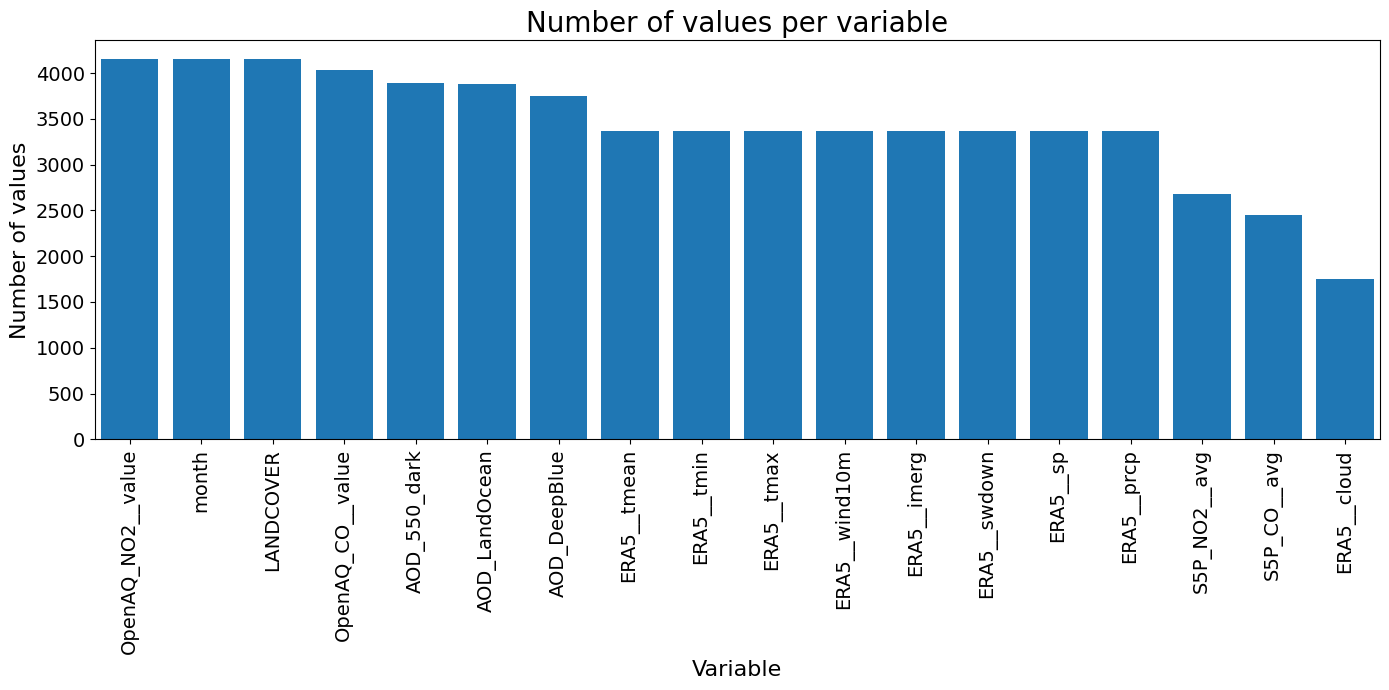

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.bar(non_missing_table["variable"], non_missing_table["non_missing_count"])
# Remove padding on the x-axis
plt.margins(x=0.005)

plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Number of values", fontsize=16)
plt.xlabel("Variable", fontsize=16)
plt.title("Number of values per variable", fontsize=20)

plt.tight_layout()
plt.show()

In [114]:
#CLEAN
features = [
    'MONTH',
    'AOD_LandOcean', #aod_land_ocean
    'ERA5__tmin', #temp_min
    'ERA5__tmin_log', #temp_min                   #LOG
    'AOD_550_dark', #aod_dark_target
    'AOD_DeepBlue_log', #aod_deep_blue_log        #LOG
    'S5P_NO2__avg_log', #s5p_no2_log              #LOG
    'ERA5__swdown', #solar_radiation
    'ERA5__swdown_log', #solar_radiation          #LOG
    'AOD_DeepBlue', #aod_deep_blue
    'ERA5__sp', #surface_pressure
    'ERA5__sp_log', #surface_pressure            #LOG
    'ERA5__prcp', #rainfall_imerg
    'AOD_550_dark_log', #aod_dark_target_log     #LOG
    'ERA5__wind10m', #wind_speed
    'ERA5__wind10m_log', #wind_speed_log         #LOG
    'AOD_LandOcean_log', #aod_land_ocean_log     #LOG
    'S5P_CO__avg', #sp5p_co               
    'ERA5__tmax', #temp_max
    'ERA5__tmax_log', #temp_max                  #LOG
    'ERA5__tmean', #temp_mean
    'ERA5__tmean_log', #temp_mean                #LOG
    'ERA5__prcp_log', #rainfall_imerg_log        #LOG
    'S5P_NO2__avg', #sp5p_no2
    'ERA5__cloud', #cloud_cover
    ##precip_log??
    'S5P_CO__avg_log', #sp5p_co_log              #LOG
    'LANDCOVER', #landcover
]


In [115]:
#NEW

import numpy as np

cols_to_log = [
    "AOD_DeepBlue",
    "S5P_NO2__avg",
    "AOD_550_dark",
    "AOD_LandOcean",
    "ERA5__prcp",
    "S5P_CO__avg",
    "ERA5__sp",
    "ERA5__wind10m",
    "ERA5__swdown",
    'ERA5__tmax', 
    'ERA5__tmean',
    'ERA5__tmin'
    
]

for col in cols_to_log:
    new_col = f"{col}_log"    # e.g., log_AOD_DeepBlue
    sub[new_col] = np.log1p(sub[col])


sub['log_NO2'] = np.log1p(sub['OpenAQ_NO2__value'])
sub['log_CO'] = np.log1p(sub['OpenAQ_CO__value'])

sub.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER', 'AOD_DeepBlue_log',
       'S5P_NO2__avg_log', 'AOD_550_dark_log', 'AOD_LandOcean_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'ERA5__sp_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__tmax_log',
       'ERA5__tmean_log', 'ERA5__tmin_log', 'log_NO2', 'log_CO'],
      dtype='object')

In [116]:
#drop columns
cols_to_keep = [
    'month',
    #'AOD_LandOcean',
    'AOD_LandOcean_log',
    #'AOD_550_dark',
    'AOD_550_dark_log',
    #'AOD_DeepBlue',
    'AOD_DeepBlue_log',
    #'ERA5__prcp',
    'ERA5__prcp_log',
    #'S5P_CO__avg',
    'S5P_CO__avg_log',
    #'S5P_NO2__avg',
    'S5P_NO2__avg_log',
    #'ERA5__wind10m',
    'ERA5__wind10m_log',
    #ERA5__swdown',
    'ERA5__swdown_log',
    #'ERA5__sp',
    'ERA5__sp_log',
    #'ERA5__tmin',
    'ERA5__tmin_log',
    #'ERA5__tmax',
    'ERA5__tmax_log',
    #'ERA5__tmean',   
    'ERA5__tmean_log', 
    'ERA5__cloud',   #do not normalize categorical
    'LANDCOVER',
    'log_NO2',      #will be used to create y
    'log_CO',        #will be used to create y
    'OpenAQ_NO2__value',
    'OpenAQ_CO__value'
    
]

sub = sub[cols_to_keep].copy()

sub.columns

Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [117]:
features = [col.replace("MONTH", "month") for col in features]

# Only keep columns that still exist in `sub`
features = [col for col in features if col in sub.columns]

for col in features:
    sub[col] = sub[col].fillna(sub[col].median())

sub.columns

Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [118]:
X = sub[features]
#Create y for model for NO2
y = sub['OpenAQ_NO2__value']


In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [120]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")


In [76]:
#DONT RUN 
#ONLY RUN ONCE - TAKES 20min TO RUN
# ========== BAYESIAN OPTIMIZATION FOR RANDOM FOREST ==========
opt = BayesSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        "n_estimators": Integer(200, 1200),
        "max_depth": Integer(5, 40),
        "min_samples_split": Integer(2, 20),
        "min_samples_leaf": Integer(1, 10),
        "max_features": Real(0.3, 1.0),
        "bootstrap": [True, False],
    },
    n_iter=35,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

print("Running optimization on real ground stations...")
opt.fit(X_train, y_train)

# Evaluation
pred = opt.best_estimator_.predict(X_test)
print(f"→ Validation on real stations")
print(f"   MAE  : {mean_absolute_error(y_test, pred):.5f}")
print(f"   R²   : {r2_score(y_test, pred):.4f}")

Running optimization on real ground stations...
→ Validation on real stations
   MAE  : 0.62261
   R²   : 0.7147


In [ ]:
#DONT RUN again
print("Best Parameters:")
for k, v in opt.best_params_.items():
    print(f"{k}: {v}")

print("\nBest Estimator:")
print(opt.best_estimator_)

print("\nBest CV neg-MAE:", opt.best_score_)

Best Parameters:
bootstrap: False
max_depth: 40
max_features: 0.385543381879357
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 1200

Best Estimator:
RandomForestRegressor(bootstrap=False, max_depth=40,
                      max_features=0.385543381879357, n_estimators=1200,
                      n_jobs=-1, random_state=42)

Best CV neg-MAE: -0.9048902605988254


In [121]:
#Cross validation on training set
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Define optimized model
rf_opt = RandomForestRegressor(
    n_estimators=1200,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    bootstrap=False,
    max_features=0.385543381879357,
    random_state=42
)

# 2. Cross-validation on training data only
cv_scores = cross_val_score(
    rf_opt,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("Cross-validation MAE scores:", -cv_scores)
print("Mean CV MAE:", -cv_scores.mean())

# 3. Fit model on full training data
rf_opt.fit(X_train, y_train)

# 4. Evaluate on test set
y_pred = rf_opt.predict(X_test)
print("R2 (log scale):", r2_score(y_test, y_pred))
print("RMSE (log scale):", np.sqrt(mean_squared_error(y_test, y_pred)))

# 5. Convert back to real scale
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

print("R2 (real scale):", r2_score(y_test_real, y_pred_real))
print("RMSE (real scale):", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))


Cross-validation MAE scores: [0.88778112 0.8818409  0.87844042 0.91858639 0.95780247]
Mean CV MAE: 0.9048902605988254
R2 (log scale): 0.7147016254838177
RMSE (log scale): 1.4629775160398872
R2 (real scale): 0.6633345615327364
RMSE (real scale): 2851.7189741491848


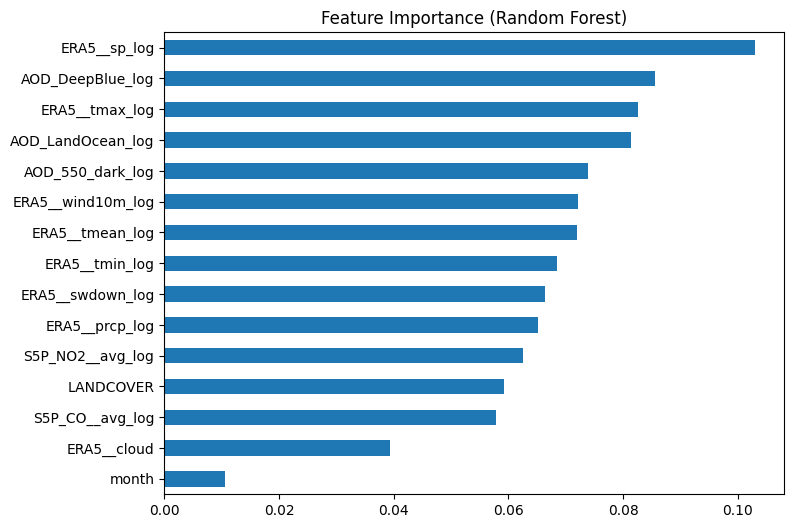

In [123]:
import matplotlib.pyplot as plt

importances = pd.Series(rf_opt.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()


In [124]:
#Predict on full dataset
#1. create dataset to use for prediction 
df.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER'],
      dtype='object')

In [125]:
for col in cols_to_log:
    new_col = f"{col}_log"    # e.g., log_AOD_DeepBlue
    df[new_col] = np.log1p(df[col])


df['log_NO2'] = np.log1p(df['OpenAQ_NO2__value'])
df['log_CO'] = np.log1p(df['OpenAQ_CO__value'])


df = df[cols_to_keep].copy()

df.columns


Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [126]:
print("Predicting rows:", df.shape)

Predicting rows: (731861, 19)


In [127]:
# Get the columns the model expects, in the right order
feature_order = rf_opt.feature_names_in_

# Select those columns from df in that order
X_pred = df[feature_order]

# Predict and add prediction column to df
df['prediction'] = rf_opt.predict(X_pred)

# Save entire dataframe with prediction column
df.to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_NO2_FINAL.csv", index=False)


In [128]:
#make df with columns, grid_id, month and prediction
merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\merged_all_FINAL.csv"
original_df= pd.read_csv(merged_all_with_landcover)

df_id_month = original_df[['grid_id', 'month']].copy()

# Append the prediction column to df_id_month
df_id_month['prediction'] = df['prediction']

# Check the final shape
print(df_id_month.shape)

# Export to csv
df_id_month.to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\df_id_month_NO2_FINAL.csv", index=False)



(731861, 3)


In [129]:
#Add coordinates for each cell 

import geopandas as gpd
# Path to GeoJSON grid file
grid = r"C:\Users\natal\Documents\UCLouvain\Data Science/india_grid_10x10km.geojson"
# Load into a GeoDataFrame
grid = gpd.read_file(grid)

# 1. Ensure grid_id in both dfs are same type (usually int)
df_id_month['grid_id'] = df_id_month['grid_id'].astype(int)
grid['grid_id'] = grid['grid_id'].astype(int)

# 2. Merge bounding box columns from grid onto df_id_month by grid_id
df_merged = df_id_month.merge(
    grid[['grid_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m', 'geometry']],
    on='grid_id',
    how='left'
)

# 3. Convert df_merged to a GeoDataFrame with geometry column and grid CRS
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# 4. Export to GeoJSON
output_path = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_NO2_FINAL_with_bbox.geojson"
gdf_merged.to_file(output_path, driver='GeoJSON')

df_merged.drop(columns='geometry').to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_NO2_FINAL_with_bbox.csv", index=False)
print(f"✅ GeoJSON and cvs saved at {output_path}")
 


✅ GeoJSON and cvs saved at C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_NO2_FINAL_with_bbox.geojson


In [130]:
#make separate file for each month

import os

# Folder to save GeoJSONs
prediction_output_folder = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned"

# Make sure the folder exists
os.makedirs(prediction_output_folder, exist_ok=True)

# Check the exact column name for month (case sensitive)
print(df_merged.columns)  # e.g., it could be 'Month' or 'month'

# Convert to GeoDataFrame with geometry and CRS from your grid
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# Let's assume it's 'Month' based on your earlier code
month_col = 'month'  # change if needed

# Get unique months
months = gdf_merged[month_col].unique()

# Loop through months and save separate GeoJSONs
for month in months:
    subset = gdf_merged[gdf_merged[month_col] == month]
    
    # Filename with zero-padded month number, e.g., 01, 02, ...
    filename = f"NO2_month_{int(month):02d}.geojson"
    
    # Full path
    filepath = os.path.join(prediction_output_folder, filename)
    
    # Save GeoJSON 
    subset.to_file(filepath, driver='GeoJSON')
    
    print(f"Saved month {month} to {filepath}")



Index(['grid_id', 'month', 'prediction', 'x_min_m', 'y_min_m', 'x_max_m',
       'y_max_m', 'geometry'],
      dtype='object')
Saved month 1 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_01.geojson
Saved month 10 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_10.geojson
Saved month 2 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_02.geojson
Saved month 3 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_03.geojson
Saved month 4 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_04.geojson
Saved month 5 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_05.geojson
Saved month 6 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_06.geojson
Saved month 7 to C:\Users

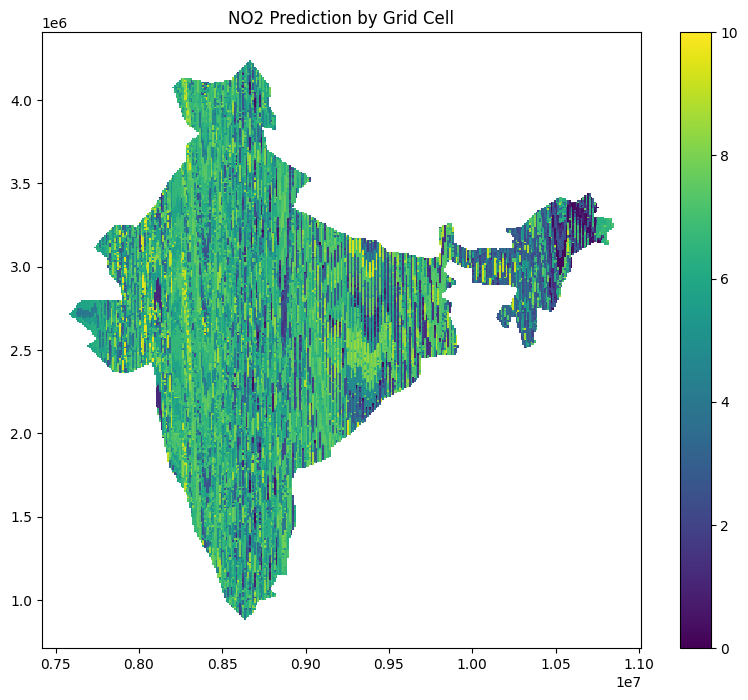

In [131]:

merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_01.geojson"
gdf_1= gpd.read_file(merged_all_with_landcover)

df = gdf_1.copy()

import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Load your CSV (assuming it contains x_min_m, y_min_m, x_max_m, y_max_m, ERA5__tmean)
df = gdf_merged.copy()

# Function to build a rectangle polygon from min/max coords
def build_polygon(row):
    return Polygon([
        (row['x_min_m'], row['y_min_m']),
        (row['x_max_m'], row['y_min_m']),
        (row['x_max_m'], row['y_max_m']),
        (row['x_min_m'], row['y_max_m'])
    ])

# Create geometry column
df['geometry'] = df.apply(build_polygon, axis=1)

# Convert to GeoDataFrame (set CRS if known, otherwise leave it blank)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:3857")  # example CRS

# Plot ERA5 temperature as choropleth
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
    column="prediction",
    cmap="viridis",       # you can change colormap
    legend=True,
    edgecolor="none",
    ax=ax
)

ax.set_title("NO2 Prediction by Grid Cell")
plt.show()


In [97]:
pip install geopandas matplotlib imageio


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [132]:
import geopandas as gpd
import matplotlib.pyplot as plt
import imageio
import os

# ---------------------------------------
# 1. Define folder and list of geojsons
# ---------------------------------------
folder = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned"

# Example naming: NO2_month_01.geojson ... NO2_month_10.geojson
files = [f"NO2_month_{str(i).zfill(2)}.geojson" for i in range(1, 11)]

# Build full paths
file_paths = [os.path.join(folder, f) for f in files]

# ---------------------------------------
# 2. Output folder for temporary PNG frames
# ---------------------------------------
frames_dir = os.path.join(folder, "frames")
os.makedirs(frames_dir, exist_ok=True)

# ---------------------------------------
# 3. Load each file, plot, and save PNG
# ---------------------------------------
frame_paths = []

for i, path in enumerate(file_paths, start=1):
    print(f"Processing: {path}")
    
    gdf = gpd.read_file(path)

    # Create figure
    fig, ax = plt.subplots(figsize=(7, 7))
    gdf.plot(column="prediction", cmap="viridis", legend=True, ax=ax)
    
    ax.set_title(f"NO2 Prediction — Month {i}", fontsize=16)
    ax.axis("off")

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{i:02d}.png")
    plt.savefig(frame_path, dpi=150, bbox_inches="tight")
    plt.close()

    frame_paths.append(frame_path)

# ---------------------------------------
# 4. Make GIF
# ---------------------------------------
gif_path = os.path.join(folder, "time_series_NO2.gif")

with imageio.get_writer(gif_path, mode="I", duration=0.7) as writer:
    for frame in frame_paths:
        image = imageio.imread(frame)
        writer.append_data(image)

print("GIF saved at:", gif_path)


Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_01.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_02.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_03.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_04.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_05.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_06.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_07.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\NO2_month_08.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\P

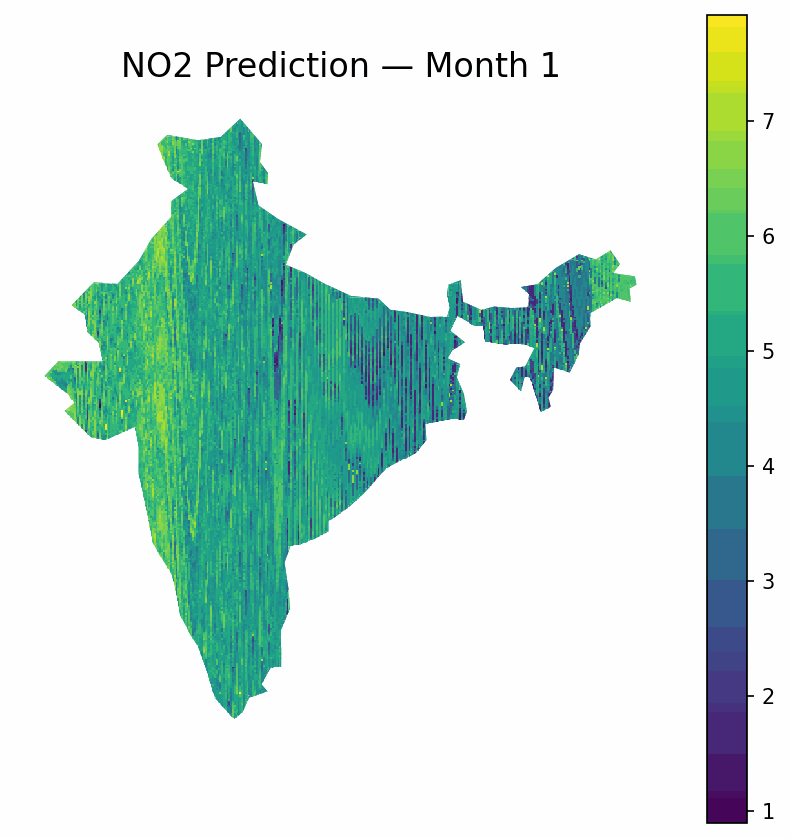

In [134]:
from IPython.display import Image

Image(filename=r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\NO2_cleaned\time_series_NO2.gif")